In [1]:
load("wild_mosaics.py")

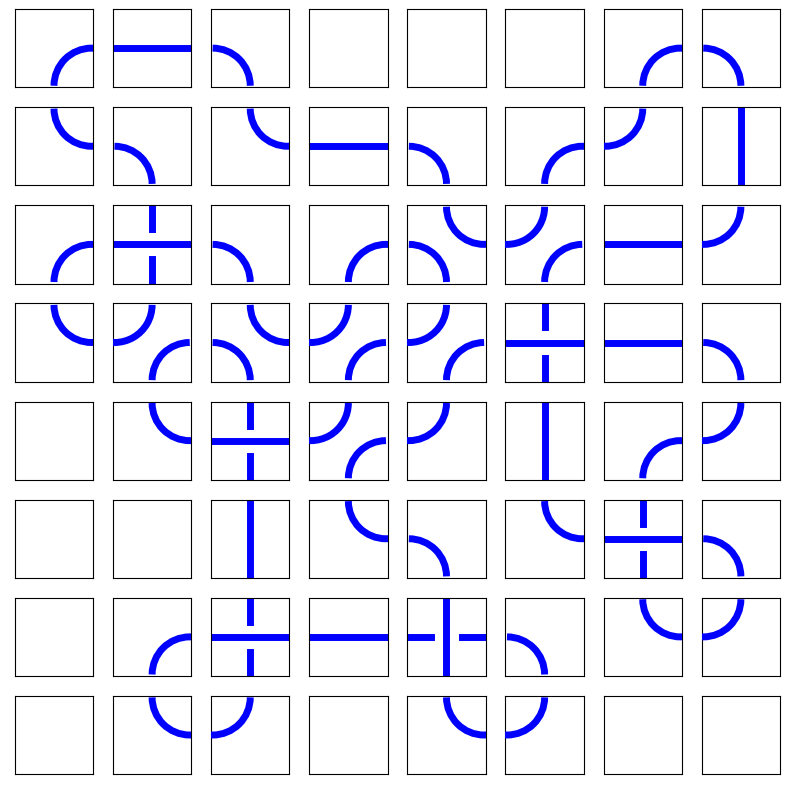

In [2]:
M = random_mosaic(8, suitably_connected = True, num_components = 1, num_crossings = 6)
M.show(8)

In [14]:
# internal function
def pick_starting_tile(M): #ensures starting tile is not crossing/hyperbolic tile
    strand_matrix = M.strandMatrix()
    for i in range(M.size):
        for j in range(M.size):
            if strand_matrix[i,j] == 1:
                return (i,j)

def crossing_handedness(tile_type, orientation_pair):
    assert tile_type in [9, 10]
    if tile_type == 9:
        if sorted(orientation_pair) == ["right", "up"]:
            return 1
        if sorted(orientation_pair) == ["down", "left"]:
            return 1
        if sorted(orientation_pair) == ["down", "right"]:
            return -1
        if sorted(orientation_pair) == ["left", "up"]:
            return -1

    if tile_type == 10:
        if sorted(orientation_pair) == ["left", "up"]:
            return 1
        if sorted(orientation_pair) == ["down", "right"]:
            return 1
        if sorted(orientation_pair) == ["down", "left"]:
            return -1
        if sorted(orientation_pair) == ["right", "up"]:
            return -1

def over_under(tile_type, orientation, numeric = False):
    assert tile_type in [9, 10]
    if tile_type == 9:
        if orientation in ["up", "down"]: 
            positioning = "under"
        if orientation in ["left", "right"]:
            positioning = "over"
    if tile_type == 10:
        if orientation in ["up", "down"]:
            positioning = "over"
        if orientation in ["left", "right"]:
            positioning = "under"
    if numeric:
        return 1 if positioning == "over" else -1 # 1 for over, -1 for under
    return positioning # "over" or "under" if numeric = False


def orientedGaussCode(M):
    res = []

    path = M.strandOf(pick_starting_tile(M)) 
    path = list(enumerate(path)) # now path is list of (index, tile)

    crossings = M.findCrossings()
    appearances = []

    for c in crossings:
        appearances += [(M.matrixRepresentation[c],c,index, path[index-1][1]) for index, tile in path if tile == c] # (tile, coord, index, previous coord)

    appearances.sort()

    orientations = []
    for appearance in appearances:
        tile, coord, index, prev_coord = appearance
        enterance = M.strandOrientationAt(coord, prev_coord)
        orientations += [(index,tile, coord, enterance, over_under(tile, enterance, numeric = True))] # (index, tile, coord, strand orientation, over/under)

    crossings = list(dict.fromkeys([crossing for index, tile, crossing, orientation, positioning in orientations])) # ensures crossings in correct order

    crossing_orientations = []

    for c in crossings:
        tile_type = M.matrixRepresentation[c]
        orientation_pair = [enterance for index, tile, crossing, enterance, positioning in orientations if crossing == c]
        crossing_orientations += [crossing_handedness(tile_type, orientation_pair)]


    res += [crossing_orientations] # the second list for the oriented Gauss code!!


    orientations.sort()

    filter = [(crossings.index(crossing) + 1)*positioning for index, tile, crossing, enterance, positioning in orientations] # can drop index, already ordered in the mode traversed

    res += [filter]

    res = [[res[1]],res[0]] # double-list the first list to match Link() format

    return res


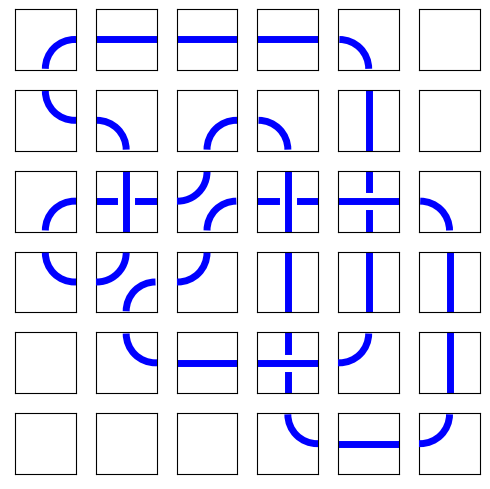

In [38]:
M = random_mosaic(6, suitably_connected = True, num_components = 1, num_crossings = 4)
M.show()

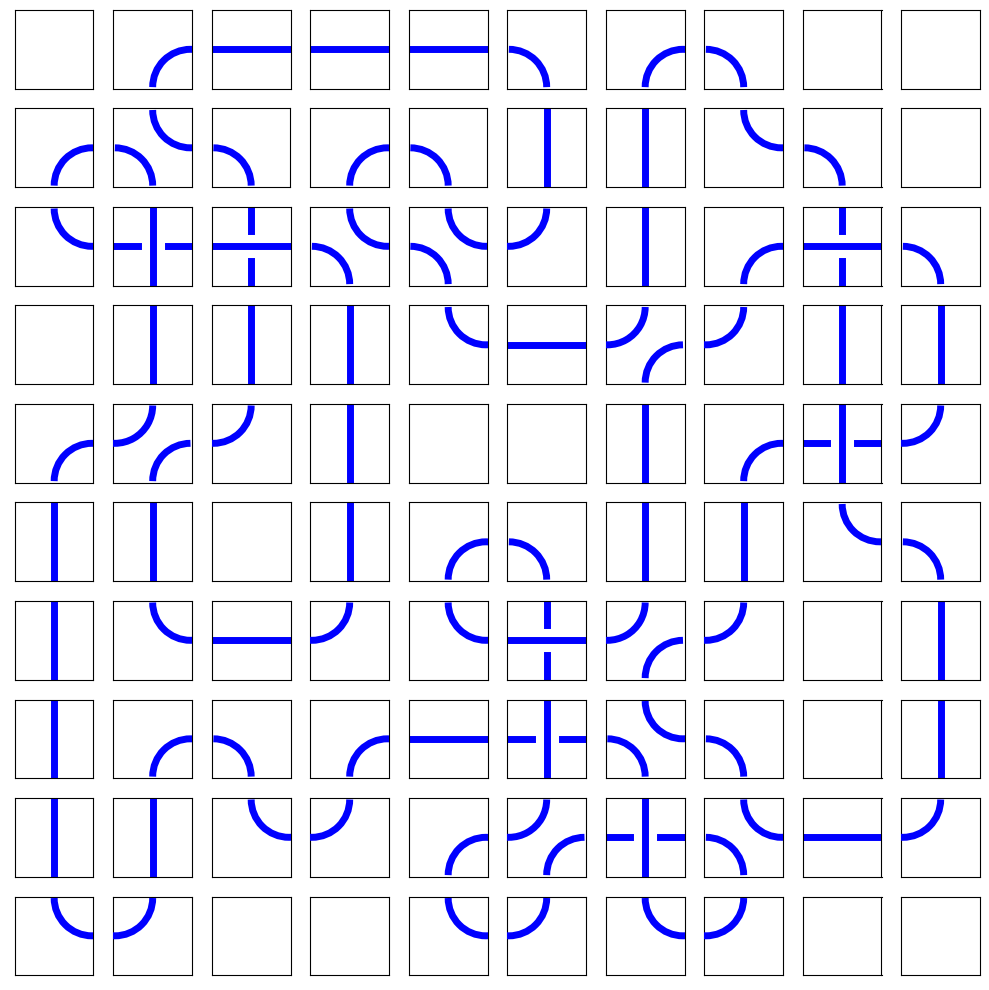

In [44]:
#M = random_mosaic(10, suitably_connected = True, num_components = 1, num_crossings = 7)
M.show(10)

In [39]:
orientedGaussCode(M)

[[[-1, 2, -4, 1, -2, 4, -3, 3]], [-1, -1, 1, -1]]

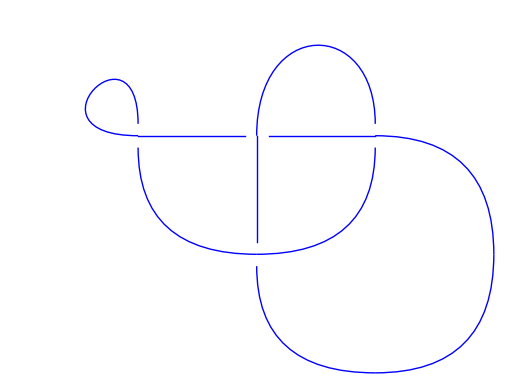

In [41]:
Link(orientedGaussCode(M)).plot()